<a href="https://colab.research.google.com/github/427paul/Machine_Learning/blob/main/DL_5_1_%EC%84%B1%EB%8A%A5_%EC%B5%9C%EC%A0%81%ED%99%94_%EC%B8%B5%EA%B3%BC_%EB%85%B8%EB%93%9C%EC%88%98.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **성능 최적화 : 층과 노드 수**

* 노드 수와 layer 수에 따른 성능 관찰
* 성능의 추세 확인

* 패션 아이템 이미지 10가지 분류하기
    * 데이터 : 이미지(1, 32, 32)
    * 10가지 클래스로 분류하기 위한 모델 생성  

    

![](https://www.researchgate.net/publication/346405197/figure/fig3/AS:962581560848384@1606508736352/Examples-of-Fashion-MNIST-dataset.ppm)


## 1.환경준비

### (1) 라이브러리 Import

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedShuffleSplit
from sklearn.metrics import *
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder

In [2]:
import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset, Subset
from torch.optim import Adam
from torchvision import datasets, transforms
from torchvision.transforms import ToTensor
from torchsummary import summary

### (2) 필요 함수 생성

* 딥러닝을 위한 데이터로더 만들기

In [3]:
def make_DataSet(x_train, x_val, y_train, y_val, batch_size = 32) :

    # 데이터 텐서로 변환
    x_train_tensor = torch.tensor(x_train, dtype=torch.float32)
    y_train_tensor = torch.tensor(y_train, dtype=torch.long)  # long = int64
    x_val_tensor = torch.tensor(x_val, dtype=torch.float32)
    y_val_tensor = torch.tensor(y_val, dtype=torch.long)

    # TensorDataset 생성 : 텐서 데이터셋으로 합치기
    train_dataset = TensorDataset(x_train_tensor, y_train_tensor)

    # DataLoader 생성
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle = True)

    return train_loader, x_val_tensor, y_val_tensor

* 학습을 위한 함수

In [4]:
def train(dataloader, model, loss_fn, optimizer, device):
    size = len(dataloader.dataset)                  # 전체 데이터셋의 크기
    num_batches = len(dataloader)                   # 배치 크기
    tr_loss = 0
    model.train()                                   # 훈련 모드로 설정(드롭아웃 및 배치 정규화와 같은 계층을 훈련 모드로 변경)
    for batch, (X, y) in enumerate(dataloader):     # batch : 현재 배치 번호, (X, y) : 입력 데이터와 레이블
        X, y = X.to(device), y.to(device)           # X.to(device), y.to(device): 입력 데이터와 레이블을 지정된 장치(device, CPU 또는 GPU)로 이동

        # Compute prediction error
        pred = model(X)
        loss = loss_fn(pred, y)
        tr_loss += loss

        # Backpropagation
        loss.backward()             # 역전파를 통해 모델의 각 파라미터에 대한 손실의 기울기를 계산
        optimizer.step()            # 옵티마이저가 계산된 기울기를 사용하여 모델의 파라미터를 업데이트
        optimizer.zero_grad()       # 옵티마이저의 기울기 값 초기화. 기울기가 누적되는 것 방지

    tr_loss /= num_batches          # 모든 배치에서의 loss 평균

    return tr_loss.item()

* 검증을 위한 함수

In [5]:
def evaluate(x_val_tensor, y_val_tensor, model, loss_fn, device):
    model.eval()                        # 모델을 평가 모드로 설정

    with torch.no_grad():               # 평가 과정에서 기울기를 계산하지 않도록 설정(메모리 사용을 줄이고 평가 속도를 높입니다.)
        x, y = x_val_tensor.to(device), y_val_tensor.to(device)
        pred = model(x)
        eval_loss = loss_fn(pred, y).item()    # 예측 값 pred와 실제 값 y 사이의 손실 계산

    return eval_loss, pred

* 학습곡선

In [6]:
def dl_learning_curve(tr_loss_list, val_loss_list, val_acc_list):

    epochs = list(range(1, len(tr_loss_list)+1))
    plt.plot(epochs, tr_loss_list, label='train_err', marker = '.')
    plt.plot(epochs, val_loss_list, label='val_err', marker = '.')
    plt.plot(epochs, val_acc_list, label='val_acc', marker = '.')

    plt.ylabel('Loss')
    plt.xlabel('Epoch')
    plt.legend()
    plt.grid()
    plt.show()

### (3) device 준비(cpu or gpu)

In [7]:
# cpu 혹은 gpu 사용
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using {device} device")

Using cuda device


### (4) 데이터 셋

* 다운로드

In [8]:
train_dataset = datasets.FashionMNIST(root='data', train=True, download=True, transform=ToTensor())
test_dataset = datasets.FashionMNIST(root='data', train=False, download=True, transform=ToTensor())

100%|██████████| 26.4M/26.4M [00:01<00:00, 19.2MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 308kB/s]
100%|██████████| 4.42M/4.42M [00:00<00:00, 5.64MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 29.8MB/s]


* 데이터 축소
    * 다양한 실험을 하기 위해 데이터 사이즈를 줄여서 진행합니다.
    * 아래 코드는 흐름만 살펴보세요. 하나하나 다 이해할 필요는 없습니다.

In [9]:
# 데이터와 레이블 추출
train_data = train_dataset.data.numpy() / 255
train_labels = train_dataset.targets.numpy()
test_data = test_dataset.data.numpy() / 255
test_labels = test_dataset.targets.numpy()

# 데이터 샘플링, 층화추출
x_train, _, y_train, _ = train_test_split(train_data, train_labels, test_size = 40000, random_state = 10, stratify = train_labels)
x_val, x_test, y_val, y_test = train_test_split(test_data, test_labels, test_size = 5000, random_state = 10, stratify = test_labels)

# 3 --> 4차원으로 변환
x_train = x_train.reshape(20000, 1, 28, 28)
x_val = x_val.reshape(5000, 1, 28, 28)
x_test = x_test.reshape(5000, 1, 28, 28)

# tensor로 변환
x_train = torch.tensor(x_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.long)
x_val = torch.tensor(x_val, dtype=torch.float32)
y_val = torch.tensor(y_val, dtype=torch.long)
x_test = torch.tensor(x_test, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.long)

# train_dataset으로 변환
train_TensorDS = TensorDataset(x_train, y_train)

* 데이터셋의 x와 y

In [10]:
x_train.shape, y_train.shape

(torch.Size([20000, 1, 28, 28]), torch.Size([20000]))

In [11]:
x_val.shape, x_test.shape

(torch.Size([5000, 1, 28, 28]), torch.Size([5000, 1, 28, 28]))

* y(target)의 클래스

In [12]:
classes = train_dataset.classes
classes

['T-shirt/top',
 'Trouser',
 'Pullover',
 'Dress',
 'Coat',
 'Sandal',
 'Shirt',
 'Sneaker',
 'Bag',
 'Ankle boot']

* train은 데이터로더로 생성

In [13]:
batch_size = 64
train_dataloader = DataLoader(train_TensorDS, batch_size=batch_size)

In [14]:
# 첫번째 배치만 로딩해서 살펴보기
for X, y in train_dataloader:
    print(f"Shape of X [batch, channels, height, width]: {X.shape}")
    print(f"Shape of y: {y.shape} {y.dtype}")
    break

Shape of X [batch, channels, height, width]: torch.Size([64, 1, 28, 28])
Shape of y: torch.Size([64]) torch.int64


## 2.모델링 : Simple

### (1) 모델 선언

In [15]:
n_class = 10

# 모델 구조 설계
model = nn.Sequential(
    nn.Conv2d(1, 4, kernel_size=3, stride=1, padding=1),
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=2, stride=2),
    nn.Flatten(),
    nn.Linear(4 * 14 * 14, n_class)
).to(device)

# 모델 요약
summary(model, input_size = (1,28,28))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1            [-1, 4, 28, 28]              40
              ReLU-2            [-1, 4, 28, 28]               0
         MaxPool2d-3            [-1, 4, 14, 14]               0
           Flatten-4                  [-1, 784]               0
            Linear-5                   [-1, 10]           7,850
Total params: 7,890
Trainable params: 7,890
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.00
Forward/backward pass size (MB): 0.06
Params size (MB): 0.03
Estimated Total Size (MB): 0.09
----------------------------------------------------------------


* Loss function과 Optimizer

In [16]:
loss_fn = nn.CrossEntropyLoss()
optimizer = Adam(model.parameters(), lr=0.001)

### (2) 학습

Epoch 1, train loss : 0.8296, val loss : 0.5574, val acc : 0.7924
Epoch 2, train loss : 0.4890, val loss : 0.4778, val acc : 0.8264
Epoch 3, train loss : 0.4353, val loss : 0.4448, val acc : 0.8420
Epoch 4, train loss : 0.4076, val loss : 0.4256, val acc : 0.8516
Epoch 5, train loss : 0.3892, val loss : 0.4128, val acc : 0.8570
Epoch 6, train loss : 0.3755, val loss : 0.4034, val acc : 0.8602
Epoch 7, train loss : 0.3647, val loss : 0.3962, val acc : 0.8620
Epoch 8, train loss : 0.3557, val loss : 0.3905, val acc : 0.8648
Epoch 9, train loss : 0.3481, val loss : 0.3860, val acc : 0.8658
Epoch 10, train loss : 0.3414, val loss : 0.3823, val acc : 0.8660
Epoch 11, train loss : 0.3353, val loss : 0.3794, val acc : 0.8682
Epoch 12, train loss : 0.3299, val loss : 0.3769, val acc : 0.8688
Epoch 13, train loss : 0.3249, val loss : 0.3749, val acc : 0.8708
Epoch 14, train loss : 0.3202, val loss : 0.3733, val acc : 0.8710
Epoch 15, train loss : 0.3159, val loss : 0.3719, val acc : 0.8714
Epoc

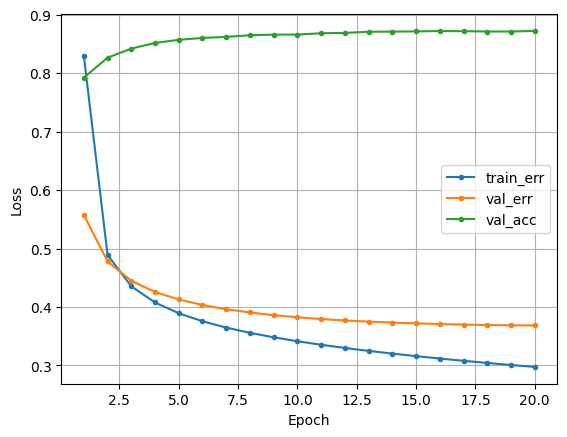

In [17]:
epochs = 20
tr_loss_list, val_loss_list, val_acc_list = [], [], []

for t in range(epochs):
    tr_loss = train(train_dataloader, model, loss_fn, optimizer, device)
    val_loss, pred = evaluate(x_val, y_val, model, loss_fn, device)

    # accuracy 측정
    pred = nn.functional.softmax(pred, dim=1)
    pred = np.argmax(pred.cpu().numpy(), axis = 1)
    acc = accuracy_score(y_val.numpy(), pred)

    # 리스트에 추가
    tr_loss_list.append(tr_loss)     # train - CrossEntropy
    val_loss_list.append(val_loss)   # val - CrossEntropy
    val_acc_list.append(acc)         # val - Accuracy

    print(f"Epoch {t+1}, train loss : {tr_loss:.4f}, val loss : {val_loss:.4f}, val acc : {acc:.4f}")

# 학습곡선
dl_learning_curve(tr_loss_list, val_loss_list, val_acc_list)

### (3) 모델 평가

In [18]:
_, pred = evaluate(x_test, y_test, model, loss_fn, device)
pred = nn.functional.softmax(pred, dim=1)
pred = np.argmax(pred.cpu().numpy(), axis = 1)

* confusion matrix

In [19]:
cm = confusion_matrix(y_test.numpy(), pred)
cm

array([[431,   0,   6,  17,   0,   1,  40,   0,   5,   0],
       [  2, 483,   0,  13,   0,   0,   1,   0,   1,   0],
       [  6,   0, 389,   7,  38,   0,  59,   0,   1,   0],
       [ 14,   5,   6, 442,  13,   0,  18,   1,   1,   0],
       [  0,   1,  31,  18, 392,   0,  58,   0,   0,   0],
       [  0,   0,   0,   1,   0, 475,   0,  19,   0,   5],
       [ 71,   2,  34,  12,  48,   0, 324,   0,   9,   0],
       [  0,   0,   0,   0,   0,   7,   0, 473,   0,  20],
       [  1,   0,   1,   2,   3,   1,   9,   3, 480,   0],
       [  0,   0,   0,   0,   0,   1,   1,  20,   0, 478]])

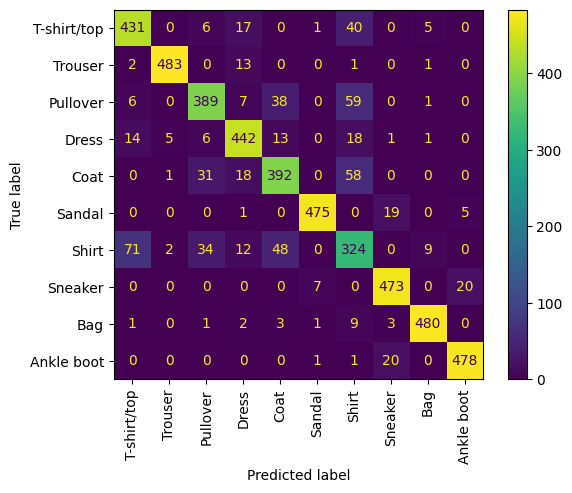

In [20]:
# confusion matrix 시각화
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
disp.plot()
plt.xticks(rotation=90)
plt.show()

* classification_report

In [21]:
print(accuracy_score(y_test.numpy(), pred))
print('-'*100)
print(classification_report(y_test.numpy(), pred, target_names=classes))

0.8734
----------------------------------------------------------------------------------------------------
              precision    recall  f1-score   support

 T-shirt/top       0.82      0.86      0.84       500
     Trouser       0.98      0.97      0.97       500
    Pullover       0.83      0.78      0.80       500
       Dress       0.86      0.88      0.87       500
        Coat       0.79      0.78      0.79       500
      Sandal       0.98      0.95      0.96       500
       Shirt       0.64      0.65      0.64       500
     Sneaker       0.92      0.95      0.93       500
         Bag       0.97      0.96      0.96       500
  Ankle boot       0.95      0.96      0.95       500

    accuracy                           0.87      5000
   macro avg       0.87      0.87      0.87      5000
weighted avg       0.87      0.87      0.87      5000



## 3.모델링 실험1 : node
* 모델 구조를 그대로 두고
* 노드 수(커널 수)만 늘려 봅시다.
    * nn.Conv2d(1, **n**, ...) ==> n을 점차 늘리면서 성능을 비교해 봅시다.
        * 예시 : 4 --> 8 --> 16 --> 32 --> 64 --> 128
        * 꼭 2^n 으로 늘어날 필요는 없습니다.

### (1) 모델 선언

In [22]:
n_class = 10
n = 8   # 이 숫자를 수정해 봅시다.

# 모델 구조 설계
model = nn.Sequential(
    nn.Conv2d(1, n, kernel_size=3, stride=1, padding=1),
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=2, stride=2),
    nn.Flatten(),
    nn.Linear(n * 14 * 14, n_class)
).to(device)

# loss, optimizer
loss_fn = nn.CrossEntropyLoss()
optimizer = Adam(model.parameters(), lr=0.001)

summary(model, input_size = (1,28,28))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1            [-1, 8, 28, 28]              80
              ReLU-2            [-1, 8, 28, 28]               0
         MaxPool2d-3            [-1, 8, 14, 14]               0
           Flatten-4                 [-1, 1568]               0
            Linear-5                   [-1, 10]          15,690
Total params: 15,770
Trainable params: 15,770
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.00
Forward/backward pass size (MB): 0.12
Params size (MB): 0.06
Estimated Total Size (MB): 0.18
----------------------------------------------------------------


### (2) 학습

Epoch 1, train loss : 0.7035, val loss : 0.5076, val acc : 0.8222
Epoch 2, train loss : 0.4541, val loss : 0.4529, val acc : 0.8402
Epoch 3, train loss : 0.4067, val loss : 0.4295, val acc : 0.8488
Epoch 4, train loss : 0.3787, val loss : 0.4122, val acc : 0.8518
Epoch 5, train loss : 0.3591, val loss : 0.3986, val acc : 0.8582
Epoch 6, train loss : 0.3439, val loss : 0.3878, val acc : 0.8626
Epoch 7, train loss : 0.3314, val loss : 0.3791, val acc : 0.8646
Epoch 8, train loss : 0.3209, val loss : 0.3720, val acc : 0.8674
Epoch 9, train loss : 0.3116, val loss : 0.3665, val acc : 0.8676
Epoch 10, train loss : 0.3035, val loss : 0.3615, val acc : 0.8704
Epoch 11, train loss : 0.2961, val loss : 0.3578, val acc : 0.8718
Epoch 12, train loss : 0.2893, val loss : 0.3545, val acc : 0.8730
Epoch 13, train loss : 0.2830, val loss : 0.3518, val acc : 0.8744
Epoch 14, train loss : 0.2771, val loss : 0.3493, val acc : 0.8750
Epoch 15, train loss : 0.2715, val loss : 0.3472, val acc : 0.8750
Epoc

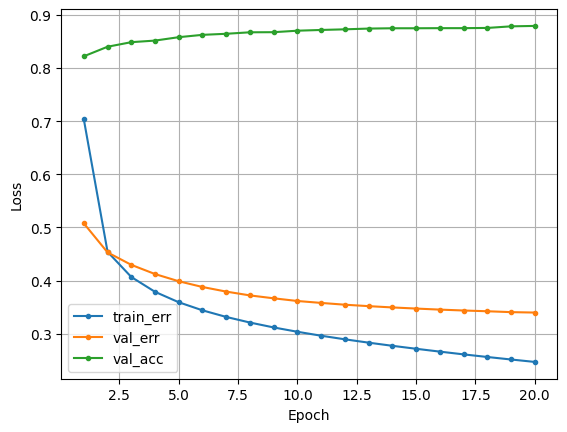

In [23]:
epochs = 20
tr_loss_list, val_loss_list, val_acc_list = [], [], []

for t in range(epochs):
    tr_loss = train(train_dataloader, model, loss_fn, optimizer, device)
    val_loss, pred = evaluate(x_val, y_val, model, loss_fn, device)

    # accuracy 측정
    pred = nn.functional.softmax(pred, dim=1)
    pred = np.argmax(pred.cpu().numpy(), axis = 1)
    acc = accuracy_score(y_val.numpy(), pred)

    # 리스트에 추가
    tr_loss_list.append(tr_loss)     # train - CrossEntropy
    val_loss_list.append(val_loss)   # val - CrossEntropy
    val_acc_list.append(acc)         # val - Accuracy

    print(f"Epoch {t+1}, train loss : {tr_loss:.4f}, val loss : {val_loss:.4f}, val acc : {acc:.4f}")

# 학습곡선
dl_learning_curve(tr_loss_list, val_loss_list, val_acc_list)

### (3) 모델 평가

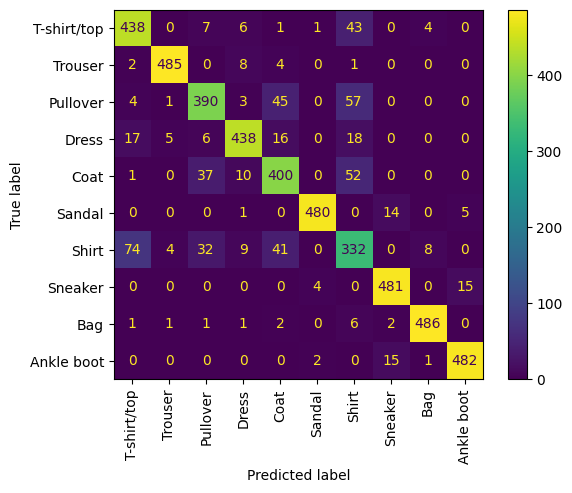

Accuracy : 0.8824
--------------------------------------------------------------------------------
              precision    recall  f1-score   support

 T-shirt/top       0.82      0.88      0.84       500
     Trouser       0.98      0.97      0.97       500
    Pullover       0.82      0.78      0.80       500
       Dress       0.92      0.88      0.90       500
        Coat       0.79      0.80      0.79       500
      Sandal       0.99      0.96      0.97       500
       Shirt       0.65      0.66      0.66       500
     Sneaker       0.94      0.96      0.95       500
         Bag       0.97      0.97      0.97       500
  Ankle boot       0.96      0.96      0.96       500

    accuracy                           0.88      5000
   macro avg       0.88      0.88      0.88      5000
weighted avg       0.88      0.88      0.88      5000



In [24]:
# 예측
_, pred = evaluate(x_test, y_test, model, loss_fn, device)
pred = nn.functional.softmax(pred, dim=1)
pred = np.argmax(pred.cpu().numpy(), axis = 1)

# confusion matrix
cm = confusion_matrix(y_test.numpy(), pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
disp.plot()
plt.xticks(rotation=90)
plt.show()

# classification report
print('='*80)
print(f'Accuracy : {accuracy_score(y_test.numpy(), pred)}')
print('-'*80)
print(classification_report(y_test.numpy(), pred, target_names=classes))

### (4) [참조]함수로 생성해서 테스트 해봅시다.

In [25]:
def make_model(node, epochs=10):

    # 모델 구조 설계
    model = nn.Sequential(
        nn.Conv2d(1, node, kernel_size=3, stride=1, padding=1),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2, stride=2),
        nn.Flatten(),
        nn.Linear(node * 14 * 14, 10)
    ).to(device)

    # loss, optimizer
    loss_fn = nn.CrossEntropyLoss()
    optimizer = Adam(model.parameters(), lr=0.001)

    # 학습
    for t in range(epochs):
        tr_loss = train(train_dataloader, model, loss_fn, optimizer, device)

    # 예측 및 평가
    _, pred = evaluate(x_test, y_test, model, loss_fn, device)
    pred = nn.functional.softmax(pred, dim=1)
    pred = np.argmax(pred.cpu().numpy(), axis = 1)

    return accuracy_score(y_test.numpy(), pred)

In [26]:
# 5 부터 101 전까지 5씩 증가시켜가며 모델링 및 성능 테스트
acc = []
for n in range(5, 101, 5) :
    acc.append(make_model(n))
    print(n)

5
10
15
20
25
30
35
40
45
50
55
60
65
70
75
80
85
90
95
100


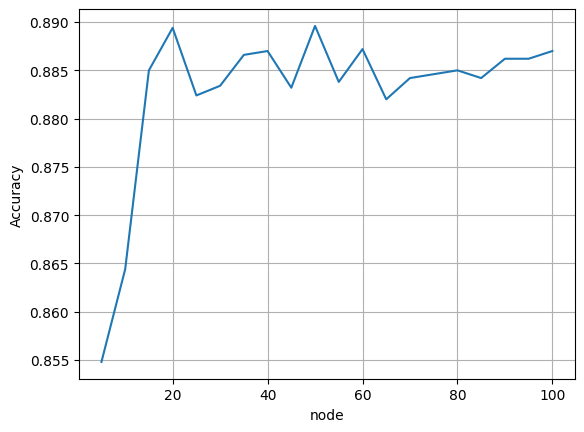

In [27]:
plt.plot(range(5, 101, 5), acc)
plt.xlabel('node')
plt.ylabel('Accuracy')
plt.grid()
plt.show()

## 4.모델링 실험2 : Layer
* 모델 구조에서 레이어를 늘려 봅시다.


### (1) Conv2d 2개

#### 1) 모델 선언

In [28]:
n_class = 10

# 모델 구조 설계
model = nn.Sequential(
    nn.Conv2d(1, 4, kernel_size=3, stride=1, padding=1),
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=2, stride=2),
    nn.Conv2d(4, 8, kernel_size=3, stride=1, padding=1),
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=2, stride=2),
    nn.Flatten(),
    nn.Linear(8 * 7 * 7, n_class)
).to(device)

# loss, optimizer
loss_fn = nn.CrossEntropyLoss()
optimizer = Adam(model.parameters(), lr=0.001)

summary(model, input_size = (1,28,28))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1            [-1, 4, 28, 28]              40
              ReLU-2            [-1, 4, 28, 28]               0
         MaxPool2d-3            [-1, 4, 14, 14]               0
            Conv2d-4            [-1, 8, 14, 14]             296
              ReLU-5            [-1, 8, 14, 14]               0
         MaxPool2d-6              [-1, 8, 7, 7]               0
           Flatten-7                  [-1, 392]               0
            Linear-8                   [-1, 10]           3,930
Total params: 4,266
Trainable params: 4,266
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.00
Forward/backward pass size (MB): 0.08
Params size (MB): 0.02
Estimated Total Size (MB): 0.10
----------------------------------------------------------------


#### 2) 학습

Epoch 1, train loss : 0.9095, val loss : 0.6419, val acc : 0.7622
Epoch 2, train loss : 0.5719, val loss : 0.5602, val acc : 0.7950
Epoch 3, train loss : 0.5098, val loss : 0.5169, val acc : 0.8088
Epoch 4, train loss : 0.4743, val loss : 0.4920, val acc : 0.8170
Epoch 5, train loss : 0.4494, val loss : 0.4748, val acc : 0.8220
Epoch 6, train loss : 0.4297, val loss : 0.4619, val acc : 0.8298
Epoch 7, train loss : 0.4139, val loss : 0.4507, val acc : 0.8334
Epoch 8, train loss : 0.4008, val loss : 0.4407, val acc : 0.8370
Epoch 9, train loss : 0.3897, val loss : 0.4322, val acc : 0.8400
Epoch 10, train loss : 0.3800, val loss : 0.4245, val acc : 0.8442
Epoch 11, train loss : 0.3713, val loss : 0.4177, val acc : 0.8480
Epoch 12, train loss : 0.3636, val loss : 0.4114, val acc : 0.8504
Epoch 13, train loss : 0.3567, val loss : 0.4054, val acc : 0.8520
Epoch 14, train loss : 0.3503, val loss : 0.3998, val acc : 0.8546
Epoch 15, train loss : 0.3446, val loss : 0.3953, val acc : 0.8558
Epoc

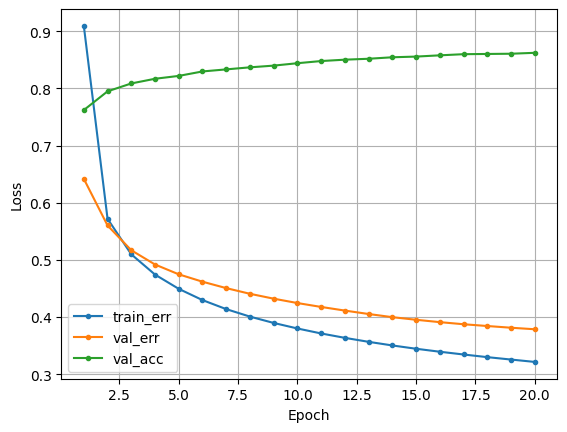

In [29]:
epochs = 20
tr_loss_list, val_loss_list, val_acc_list = [], [], []

for t in range(epochs):
    tr_loss = train(train_dataloader, model, loss_fn, optimizer, device)
    val_loss, pred = evaluate(x_val, y_val, model, loss_fn, device)

    # accuracy 측정
    pred = nn.functional.softmax(pred, dim=1)
    pred = np.argmax(pred.cpu().numpy(), axis = 1)
    acc = accuracy_score(y_val.numpy(), pred)

    # 리스트에 추가
    tr_loss_list.append(tr_loss)     # train - CrossEntropy
    val_loss_list.append(val_loss)   # val - CrossEntropy
    val_acc_list.append(acc)         # val - Accuracy

    print(f"Epoch {t+1}, train loss : {tr_loss:.4f}, val loss : {val_loss:.4f}, val acc : {acc:.4f}")

# 학습곡선
dl_learning_curve(tr_loss_list, val_loss_list, val_acc_list)

#### 3) 모델 평가

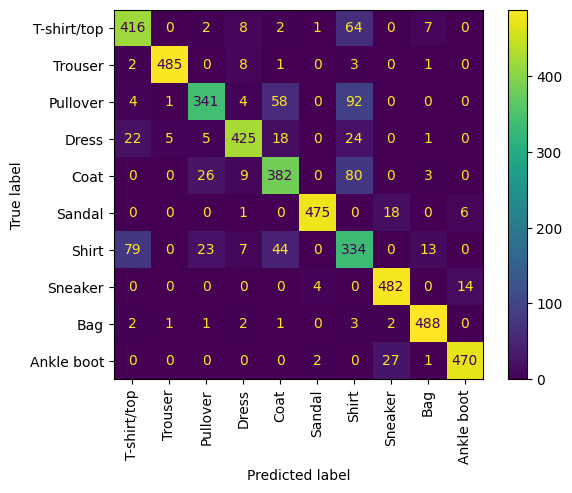

Accuracy : 0.8596
--------------------------------------------------------------------------------
              precision    recall  f1-score   support

 T-shirt/top       0.79      0.83      0.81       500
     Trouser       0.99      0.97      0.98       500
    Pullover       0.86      0.68      0.76       500
       Dress       0.92      0.85      0.88       500
        Coat       0.75      0.76      0.76       500
      Sandal       0.99      0.95      0.97       500
       Shirt       0.56      0.67      0.61       500
     Sneaker       0.91      0.96      0.94       500
         Bag       0.95      0.98      0.96       500
  Ankle boot       0.96      0.94      0.95       500

    accuracy                           0.86      5000
   macro avg       0.87      0.86      0.86      5000
weighted avg       0.87      0.86      0.86      5000



In [30]:
# 예측
_, pred = evaluate(x_test, y_test, model, loss_fn, device)
pred = nn.functional.softmax(pred, dim=1)
pred = np.argmax(pred.cpu().numpy(), axis = 1)

# confusion matrix
cm = confusion_matrix(y_test.numpy(), pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
disp.plot()
plt.xticks(rotation=90)
plt.show()

# classification report
print('='*80)
print(f'Accuracy : {accuracy_score(y_test.numpy(), pred)}')
print('-'*80)
print(classification_report(y_test.numpy(), pred, target_names=classes))

### (2) Conv2d 3개

#### 1) 모델 선언

In [31]:
n_class = 10

# 모델 구조 설계
model = nn.Sequential(
    nn.Conv2d(1, 4, kernel_size=3, stride=1, padding=1),
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=2, stride=2),
    nn.Conv2d(4, 8, kernel_size=3, stride=1, padding=1),
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=2, stride=2),
    nn.Conv2d(8, 16, kernel_size=3, stride=1, padding=1),
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=2, stride=2),
    nn.Flatten(),
    nn.Linear(16 * 3 * 3, n_class)
).to(device)

# loss, optimizer
loss_fn = nn.CrossEntropyLoss()
optimizer = Adam(model.parameters(), lr=0.001)

summary(model, input_size = (1,28,28))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1            [-1, 4, 28, 28]              40
              ReLU-2            [-1, 4, 28, 28]               0
         MaxPool2d-3            [-1, 4, 14, 14]               0
            Conv2d-4            [-1, 8, 14, 14]             296
              ReLU-5            [-1, 8, 14, 14]               0
         MaxPool2d-6              [-1, 8, 7, 7]               0
            Conv2d-7             [-1, 16, 7, 7]           1,168
              ReLU-8             [-1, 16, 7, 7]               0
         MaxPool2d-9             [-1, 16, 3, 3]               0
          Flatten-10                  [-1, 144]               0
           Linear-11                   [-1, 10]           1,450
Total params: 2,954
Trainable params: 2,954
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.00
Forward/back

#### 2) 학습

Epoch 1, train loss : 1.1317, val loss : 0.7364, val acc : 0.7174
Epoch 2, train loss : 0.6476, val loss : 0.6341, val acc : 0.7638
Epoch 3, train loss : 0.5618, val loss : 0.5883, val acc : 0.7786
Epoch 4, train loss : 0.5170, val loss : 0.5552, val acc : 0.7970
Epoch 5, train loss : 0.4882, val loss : 0.5311, val acc : 0.8044
Epoch 6, train loss : 0.4672, val loss : 0.5175, val acc : 0.8114
Epoch 7, train loss : 0.4499, val loss : 0.5056, val acc : 0.8198
Epoch 8, train loss : 0.4354, val loss : 0.4951, val acc : 0.8216
Epoch 9, train loss : 0.4235, val loss : 0.4847, val acc : 0.8244
Epoch 10, train loss : 0.4129, val loss : 0.4766, val acc : 0.8276
Epoch 11, train loss : 0.4040, val loss : 0.4674, val acc : 0.8328
Epoch 12, train loss : 0.3960, val loss : 0.4611, val acc : 0.8358
Epoch 13, train loss : 0.3887, val loss : 0.4545, val acc : 0.8380
Epoch 14, train loss : 0.3819, val loss : 0.4481, val acc : 0.8404
Epoch 15, train loss : 0.3755, val loss : 0.4427, val acc : 0.8416
Epoc

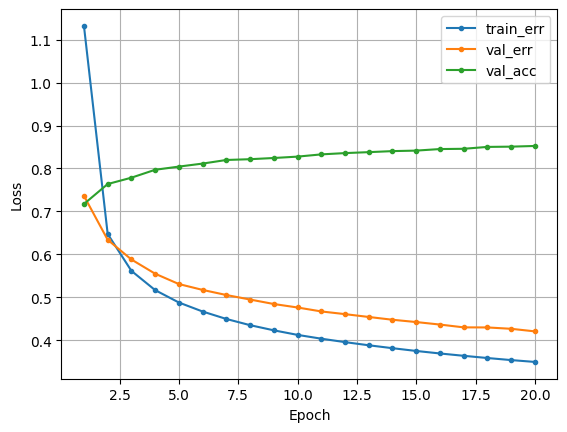

In [32]:
epochs = 20
tr_loss_list, val_loss_list, val_acc_list = [], [], []

for t in range(epochs):
    tr_loss = train(train_dataloader, model, loss_fn, optimizer, device)
    val_loss, pred = evaluate(x_val, y_val, model, loss_fn, device)

    # accuracy 측정
    pred = nn.functional.softmax(pred, dim=1)
    pred = np.argmax(pred.cpu().numpy(), axis = 1)
    acc = accuracy_score(y_val.numpy(), pred)

    # 리스트에 추가
    tr_loss_list.append(tr_loss)     # train - CrossEntropy
    val_loss_list.append(val_loss)   # val - CrossEntropy
    val_acc_list.append(acc)         # val - Accuracy

    print(f"Epoch {t+1}, train loss : {tr_loss:.4f}, val loss : {val_loss:.4f}, val acc : {acc:.4f}")

# 학습곡선
dl_learning_curve(tr_loss_list, val_loss_list, val_acc_list)

#### 3) 모델 평가

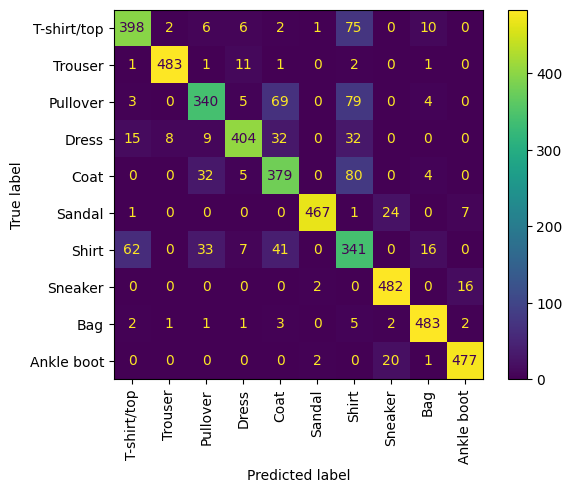

Accuracy : 0.8508
--------------------------------------------------------------------------------
              precision    recall  f1-score   support

 T-shirt/top       0.83      0.80      0.81       500
     Trouser       0.98      0.97      0.97       500
    Pullover       0.81      0.68      0.74       500
       Dress       0.92      0.81      0.86       500
        Coat       0.72      0.76      0.74       500
      Sandal       0.99      0.93      0.96       500
       Shirt       0.55      0.68      0.61       500
     Sneaker       0.91      0.96      0.94       500
         Bag       0.93      0.97      0.95       500
  Ankle boot       0.95      0.95      0.95       500

    accuracy                           0.85      5000
   macro avg       0.86      0.85      0.85      5000
weighted avg       0.86      0.85      0.85      5000



In [33]:
# 예측
_, pred = evaluate(x_test, y_test, model, loss_fn, device)
pred = nn.functional.softmax(pred, dim=1)
pred = np.argmax(pred.cpu().numpy(), axis = 1)

# confusion matrix
cm = confusion_matrix(y_test.numpy(), pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
disp.plot()
plt.xticks(rotation=90)
plt.show()

# classification report
print('='*80)
print(f'Accuracy : {accuracy_score(y_test.numpy(), pred)}')
print('-'*80)
print(classification_report(y_test.numpy(), pred, target_names=classes))

### (3) 실습
* 4-(2) 모델에서 Dense Layer(nn.Linear()) 수와 노드수를 점차 조정하며 성능을 확인해 봅시다.

#### 1) 모델 선언

In [38]:
n_class = 10

# 모델 구조 설계
model = nn.Sequential(
    nn.Conv2d(1, 16, kernel_size=3, stride=1, padding=1),
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=2, stride=2),
    nn.Conv2d(16, 32, kernel_size=3, stride=1, padding=1),
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=2, stride=2),
    nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1),
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=2, stride=2),
    nn.Flatten(),
    nn.Linear(64 * 3 * 3, 128), ## hidden layer 2개 추가
    nn.ReLU(),
    nn.Linear(128, 32),
    nn.ReLU(),
    nn.Linear(32, n_class)
).to(device)

# loss, optimizer
loss_fn = nn.CrossEntropyLoss()
optimizer = Adam(model.parameters(), lr=0.001)

summary(model, input_size = (1,28,28))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 16, 28, 28]             160
              ReLU-2           [-1, 16, 28, 28]               0
         MaxPool2d-3           [-1, 16, 14, 14]               0
            Conv2d-4           [-1, 32, 14, 14]           4,640
              ReLU-5           [-1, 32, 14, 14]               0
         MaxPool2d-6             [-1, 32, 7, 7]               0
            Conv2d-7             [-1, 64, 7, 7]          18,496
              ReLU-8             [-1, 64, 7, 7]               0
         MaxPool2d-9             [-1, 64, 3, 3]               0
          Flatten-10                  [-1, 576]               0
           Linear-11                  [-1, 128]          73,856
             ReLU-12                  [-1, 128]               0
           Linear-13                   [-1, 32]           4,128
             ReLU-14                   

#### 2) 학습

Epoch 1, train loss : 0.9367, val loss : 0.6393, val acc : 0.7588
Epoch 2, train loss : 0.5834, val loss : 0.5328, val acc : 0.8058
Epoch 3, train loss : 0.4770, val loss : 0.4410, val acc : 0.8410
Epoch 4, train loss : 0.4154, val loss : 0.4082, val acc : 0.8540
Epoch 5, train loss : 0.3731, val loss : 0.3909, val acc : 0.8616
Epoch 6, train loss : 0.3447, val loss : 0.3804, val acc : 0.8648
Epoch 7, train loss : 0.3231, val loss : 0.3670, val acc : 0.8720
Epoch 8, train loss : 0.3050, val loss : 0.3584, val acc : 0.8754
Epoch 9, train loss : 0.2888, val loss : 0.3549, val acc : 0.8770
Epoch 10, train loss : 0.2765, val loss : 0.3621, val acc : 0.8742
Epoch 11, train loss : 0.2620, val loss : 0.3599, val acc : 0.8752
Epoch 12, train loss : 0.2479, val loss : 0.3584, val acc : 0.8748
Epoch 13, train loss : 0.2352, val loss : 0.3512, val acc : 0.8798
Epoch 14, train loss : 0.2229, val loss : 0.3484, val acc : 0.8800
Epoch 15, train loss : 0.2109, val loss : 0.3426, val acc : 0.8796
Epoc

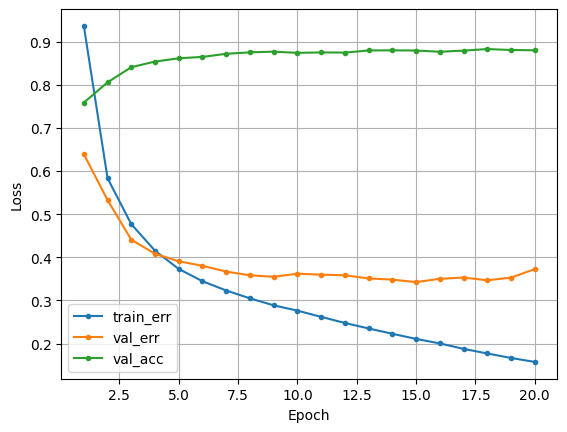

In [39]:
epochs = 20
tr_loss_list, val_loss_list, val_acc_list = [], [], []

for t in range(epochs):
    tr_loss = train(train_dataloader, model, loss_fn, optimizer, device)
    val_loss, pred = evaluate(x_val, y_val, model, loss_fn, device)

    # accuracy 측정
    pred = nn.functional.softmax(pred, dim=1)
    pred = np.argmax(pred.cpu().numpy(), axis = 1)
    acc = accuracy_score(y_val.numpy(), pred)

    # 리스트에 추가
    tr_loss_list.append(tr_loss)     # train - CrossEntropy
    val_loss_list.append(val_loss)   # val - CrossEntropy
    val_acc_list.append(acc)         # val - Accuracy

    print(f"Epoch {t+1}, train loss : {tr_loss:.4f}, val loss : {val_loss:.4f}, val acc : {acc:.4f}")

# 학습곡선
dl_learning_curve(tr_loss_list, val_loss_list, val_acc_list)

#### 3) 모델 평가

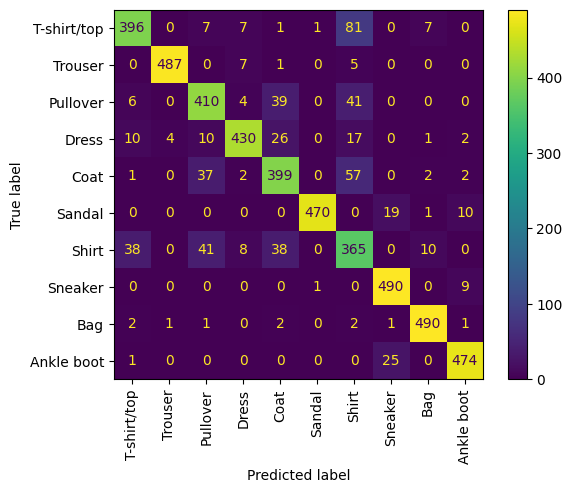

Accuracy : 0.8822
--------------------------------------------------------------------------------
              precision    recall  f1-score   support

 T-shirt/top       0.87      0.79      0.83       500
     Trouser       0.99      0.97      0.98       500
    Pullover       0.81      0.82      0.82       500
       Dress       0.94      0.86      0.90       500
        Coat       0.79      0.80      0.79       500
      Sandal       1.00      0.94      0.97       500
       Shirt       0.64      0.73      0.68       500
     Sneaker       0.92      0.98      0.95       500
         Bag       0.96      0.98      0.97       500
  Ankle boot       0.95      0.95      0.95       500

    accuracy                           0.88      5000
   macro avg       0.89      0.88      0.88      5000
weighted avg       0.89      0.88      0.88      5000



In [40]:
# 예측
_, pred = evaluate(x_test, y_test, model, loss_fn, device)
pred = nn.functional.softmax(pred, dim=1)
pred = np.argmax(pred.cpu().numpy(), axis = 1)

# confusion matrix
cm = confusion_matrix(y_test.numpy(), pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
disp.plot()
plt.xticks(rotation=90)
plt.show()

# classification report
print('='*80)
print(f'Accuracy : {accuracy_score(y_test.numpy(), pred)}')
print('-'*80)
print(classification_report(y_test.numpy(), pred, target_names=classes))